# Image classification CIFAR 10

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from tensorflow import keras


# sklearn utilities
from sklearn.dummy import DummyClassifier
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedShuffleSplit, GridSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import joblib

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
data = keras.datasets.cifar10.load_data()

In [3]:
(x_train_full, y_train_full), (x_test, y_test) = data

y_train_full = y_train_full.ravel()
y_test = y_test.ravel()

print("Shape of X_train:", x_train_full.shape)
print("Shape of y_train:", y_train_full.shape)
print("Shape of X_test:", x_test.shape)
print("Shape of y_test:", y_test.shape)


Shape of X_train: (50000, 32, 32, 3)
Shape of y_train: (50000,)
Shape of X_test: (10000, 32, 32, 3)
Shape of y_test: (10000,)


# Exploration des données

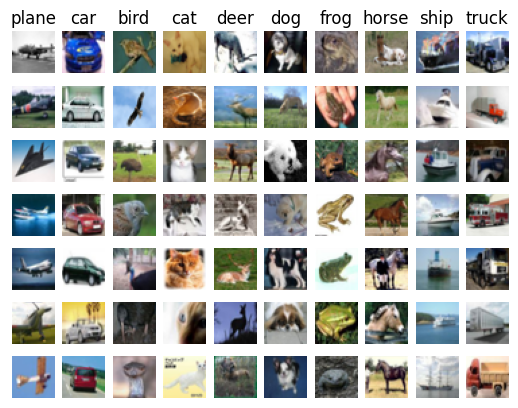

In [4]:
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
num_classes = len(classes)
samples_per_class = 7
for y, cls in enumerate(classes):
    idxs = np.flatnonzero(y_train_full == y)
    idxs = np.random.choice(idxs, samples_per_class, replace=False)
    for i, idx in enumerate(idxs):
        plt_idx = i * num_classes + y + 1
        plt.subplot(samples_per_class, num_classes, plt_idx)
        plt.imshow(x_train_full[idx].astype('uint8'))
        plt.axis('off')
        if i == 0:
            plt.title(cls)
plt.show()

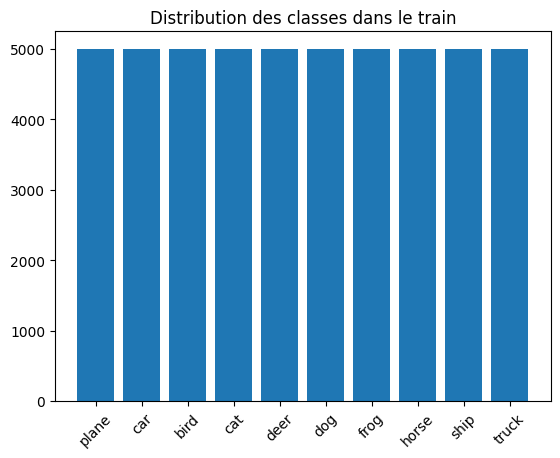

In [5]:
# Distribution of classes
unique, counts = np.unique(y_train_full, return_counts=True)
plt.bar(unique, counts)
plt.xticks(unique, classes, rotation=45)
plt.title('Distribution des classes dans le train')
plt.show()

# Prétraitement

In [6]:
# Flatten images
x_train_flat = x_train_full.reshape(x_train_full.shape[0], -1)
x_test_flat = x_test.reshape(x_test.shape[0], -1)

# Normalize to [0,1]
x_train_norm = x_train_flat / 255.0
x_test_norm = x_test_flat / 255.0

# Flatten labels
y_train_flat = y_train_full.flatten()
y_test_flat = y_test.flatten()

print("Shape after flattening:", x_train_norm.shape)

Shape after flattening: (50000, 3072)


# Division des données

In [7]:
# Split train into train and validation
x_train, x_val, y_train, y_val = train_test_split(x_train_norm, y_train_flat, test_size=0.2, random_state=RANDOM_STATE, stratify=y_train_flat)

print("Train shape:", x_train.shape)
print("Val shape:", x_val.shape)


Train shape: (40000, 3072)
Val shape: (10000, 3072)


# Modèle de base aléatoire

In [8]:
baseline = DummyClassifier(strategy='uniform', random_state=RANDOM_STATE)
baseline.fit(x_train, y_train)
y_val_pred = baseline.predict(x_val)
print('\nBaseline accuracy on val:', accuracy_score(y_val, y_val_pred))
print('\nClassification report:\n', classification_report(y_val, y_val_pred, target_names=classes))


Baseline accuracy on val: 0.0976

Classification report:
               precision    recall  f1-score   support

       plane       0.09      0.10      0.10      1000
         car       0.09      0.09      0.09      1000
        bird       0.09      0.09      0.09      1000
         cat       0.09      0.08      0.08      1000
        deer       0.12      0.11      0.11      1000
         dog       0.10      0.10      0.10      1000
        frog       0.11      0.11      0.11      1000
       horse       0.09      0.09      0.09      1000
        ship       0.10      0.10      0.10      1000
       truck       0.10      0.11      0.11      1000

    accuracy                           0.10     10000
   macro avg       0.10      0.10      0.10     10000
weighted avg       0.10      0.10      0.10     10000



In [9]:
def tune_and_evaluate(pipeline, param_grid, X_train, y_train, X_val, y_val, model_name, cv=3):

    print('\n---', model_name, '---')
    
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=RANDOM_STATE)
    
    gs = GridSearchCV(pipeline, param_grid, cv=skf, scoring='accuracy', n_jobs=1, verbose=1)
    gs.fit(X_train, y_train)
    print('Best params:', gs.best_params_)
    print('Best CV score:', gs.best_score_)
    
    best = gs.best_estimator_
    y_pred_val = best.predict(X_val)
    print('Val accuracy:', accuracy_score(y_val, y_pred_val))
    print('\nClassification report on val:\n', classification_report(y_val, y_pred_val, target_names=classes))
    
    cm = confusion_matrix(y_val, y_pred_val, labels=range(len(classes)))
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    
    fig, ax = plt.subplots(figsize=(8,8))
    
    disp.plot(ax=ax, xticks_rotation='vertical')
    
    plt.title(f'Confusion matrix: {model_name} (val)')
    plt.show()
    
    return gs

# Régression logistique multinomiale


--- Logistic Regression ---
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best params: {'lr__C': 0.1, 'pca__n_components': 100}
Best CV score: 0.3933500054915502
Val accuracy: 0.3994

Classification report on val:
               precision    recall  f1-score   support

       plane       0.45      0.48      0.47      1000
         car       0.43      0.48      0.45      1000
        bird       0.33      0.27      0.30      1000
         cat       0.30      0.26      0.28      1000
        deer       0.36      0.28      0.32      1000
         dog       0.34      0.34      0.34      1000
        frog       0.40      0.50      0.44      1000
       horse       0.41      0.39      0.40      1000
        ship       0.48      0.51      0.49      1000
       truck       0.44      0.48      0.46      1000

    accuracy                           0.40     10000
   macro avg       0.39      0.40      0.39     10000
weighted avg       0.39      0.40      0.39     10000



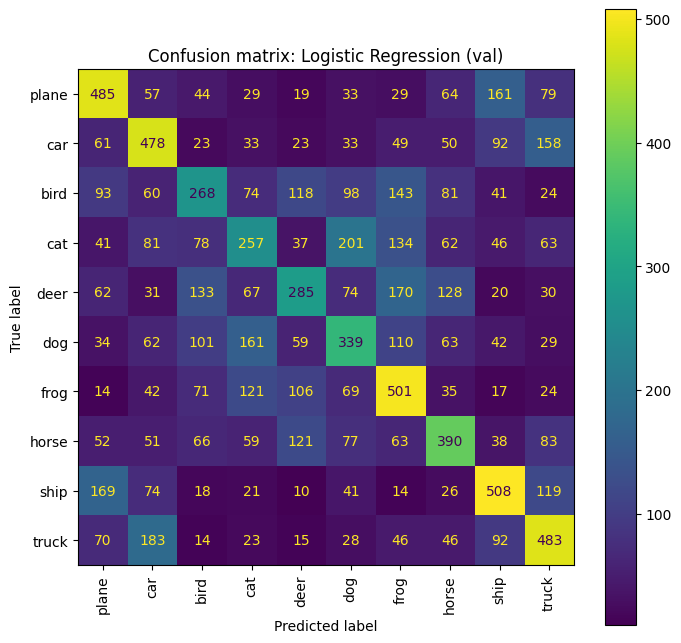

In [13]:
# Logistic Regression with Pipeline and PCA
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=200)),
    ('lr', LogisticRegression(solver='saga', 
    max_iter=1000, penalty='l2', 
    random_state=RANDOM_STATE))
])

param_grid_lr = {
    'pca__n_components': [50, 100], 
    'lr__C': [0.1, 1, 10]
}

grid_lr = tune_and_evaluate(pipeline_lr, param_grid_lr, x_train, y_train, x_val, y_val, 'Logistic Regression')

# SVM sans noyau


--- SVM Linear ---
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best params: {'pca__n_components': 100, 'svm__C': 0.01}
Best CV score: 0.388425056734113
Val accuracy: 0.3929

Classification report on val:
               precision    recall  f1-score   support

       plane       0.42      0.48      0.45      1000
         car       0.39      0.51      0.44      1000
        bird       0.36      0.17      0.24      1000
         cat       0.33      0.17      0.23      1000
        deer       0.38      0.23      0.28      1000
         dog       0.37      0.35      0.36      1000
        frog       0.36      0.56      0.44      1000
       horse       0.41      0.42      0.41      1000
        ship       0.46      0.55      0.50      1000
       truck       0.41      0.49      0.44      1000

    accuracy                           0.39     10000
   macro avg       0.39      0.39      0.38     10000
weighted avg       0.39      0.39      0.38     10000



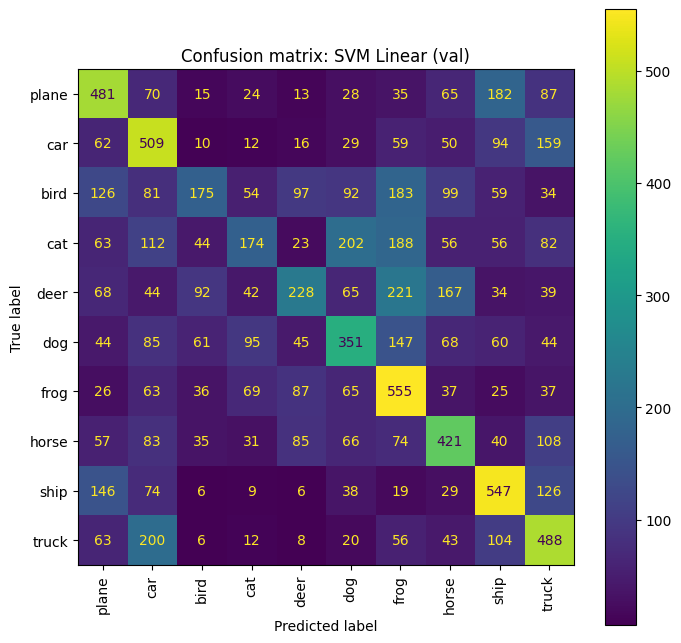

In [15]:
# Linear SVM with Pipeline and PCA
pipeline_svm_linear = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=200)),
    ('svm', LinearSVC(random_state=RANDOM_STATE, max_iter=8000))
])

param_grid_svm_linear = {
    'pca__n_components': [50, 100], 
    'svm__C': [0.01, 0.1, 1, 10]
}

grid_svm_linear = tune_and_evaluate(pipeline_svm_linear, param_grid_svm_linear, x_train, y_train, x_val, y_val, 'SVM Linear')

# SVM avec noyau


--- SVM RBF ---
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best params: {'pca__n_components': 100, 'svm__C': 10, 'svm__gamma': 0.001}
Best CV score: 0.5235752556480778
Val accuracy: 0.5527

Classification report on val:
               precision    recall  f1-score   support

       plane       0.63      0.61      0.62      1000
         car       0.63      0.65      0.64      1000
        bird       0.46      0.46      0.46      1000
         cat       0.35      0.42      0.38      1000
        deer       0.51      0.46      0.48      1000
         dog       0.47      0.47      0.47      1000
        frog       0.62      0.55      0.59      1000
       horse       0.66      0.57      0.62      1000
        ship       0.69      0.67      0.68      1000
       truck       0.57      0.66      0.61      1000

    accuracy                           0.55     10000
   macro avg       0.56      0.55      0.55     10000
weighted avg       0.56      0.55      0.55     10000



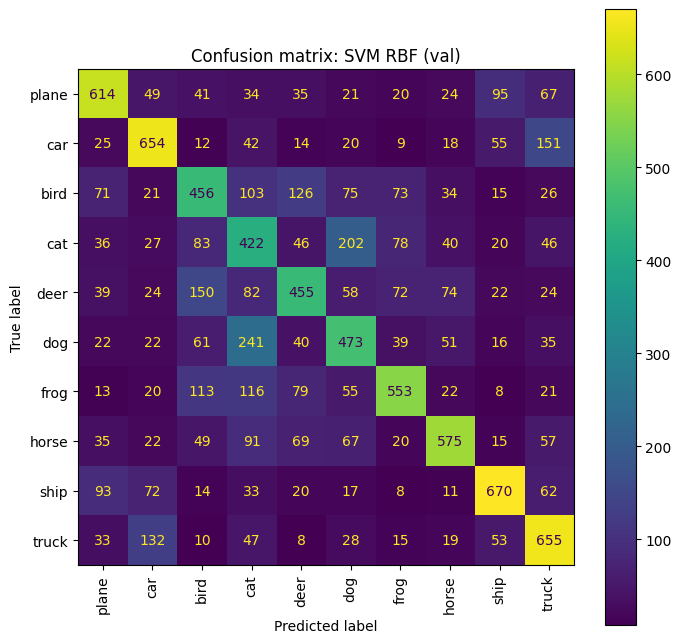

In [16]:
# RBF SVM with Pipeline and PCA
pipeline_svm_rbf = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=200)), 
    ('svm', SVC(kernel='rbf', random_state=RANDOM_STATE))
])

param_grid_svm_rbf = {
    'pca__n_components': [50, 100], 
    'svm__C': [1, 10], 
    'svm__gamma': [0.001, 0.01, 0.1]
}

grid_svm_rbf = tune_and_evaluate(pipeline_svm_rbf, param_grid_svm_rbf, x_train, y_train, x_val, y_val, 'SVM RBF')

# k-voisins les plus proches


--- KNN ---
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best params: {'knn__n_neighbors': 9, 'pca__n_components': 50}
Best CV score: 0.3746249967183633
Val accuracy: 0.3836

Classification report on val:
               precision    recall  f1-score   support

       plane       0.43      0.58      0.49      1000
         car       0.58      0.31      0.40      1000
        bird       0.26      0.40      0.31      1000
         cat       0.34      0.21      0.26      1000
        deer       0.26      0.45      0.33      1000
         dog       0.42      0.22      0.29      1000
        frog       0.33      0.48      0.39      1000
       horse       0.57      0.30      0.39      1000
        ship       0.47      0.61      0.53      1000
       truck       0.66      0.28      0.39      1000

    accuracy                           0.38     10000
   macro avg       0.43      0.38      0.38     10000
weighted avg       0.43      0.38      0.38     10000



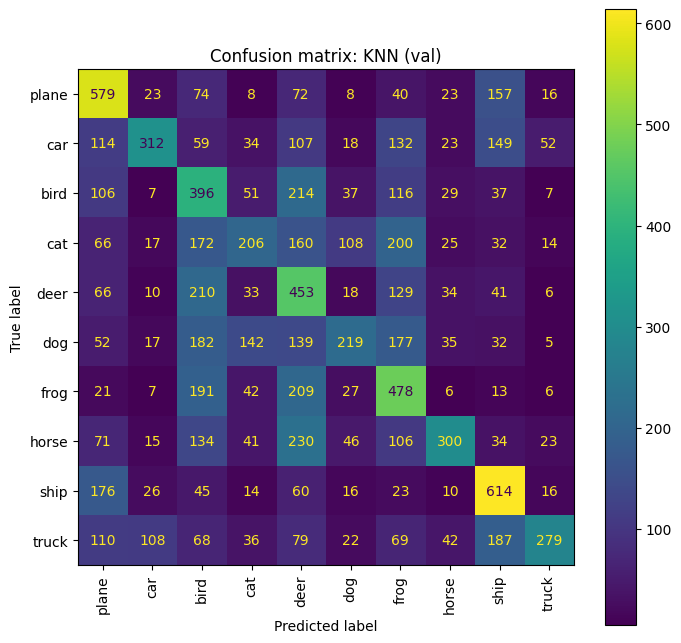

In [19]:
# KNN with Pipeline and PCA
pipeline_knn = Pipeline([
    ('pca', PCA(n_components=200)),
    ('knn', KNeighborsClassifier())
])

param_grid_knn = {
    'pca__n_components': [50, 100], 
    'knn__n_neighbors': [3, 5, 7, 9]
}

grid_knn = tune_and_evaluate(pipeline_knn, param_grid_knn, x_train, y_train, x_val, y_val, 'KNN')

# Évaluation finale sur le test

In [22]:
# Evaluate on test with best models
y_test_pred_lr = grid_lr.best_estimator_.predict(x_test_norm)
acc_test_lr = accuracy_score(y_test_flat, y_test_pred_lr)

y_test_pred_svm_linear = grid_svm_linear.best_estimator_.predict(x_test_norm)
acc_test_svm_linear = accuracy_score(y_test_flat, y_test_pred_svm_linear)

y_test_pred_svm_rbf = grid_svm_rbf.best_estimator_.predict(x_test_norm)
acc_test_svm_rbf = accuracy_score(y_test_flat, y_test_pred_svm_rbf)

y_test_pred_knn = grid_knn.best_estimator_.predict(x_test_norm)
acc_test_knn = accuracy_score(y_test_flat, y_test_pred_knn)

print("Test accuracies:")
print("LR:", acc_test_lr)
print("SVM Linear:", acc_test_svm_linear)
print("SVM RBF:", acc_test_svm_rbf)
print("KNN:", acc_test_knn)

Test accuracies:
LR: 0.401
SVM Linear: 0.395
SVM RBF: 0.5445
KNN: 0.3925


# Conclusion

In [26]:
print("\nMeilleur modèle sur l'ensemble de test :")
best_acc = max(acc_test_lr, acc_test_svm_linear, acc_test_svm_rbf, acc_test_knn)
if best_acc == acc_test_lr:
    best_model = grid_lr.best_estimator_
    best_name = 'Logistic Regression'
    y_test_pred_best = y_test_pred_lr
elif best_acc == acc_test_svm_linear:
    best_model = grid_svm_linear.best_estimator_
    best_name = 'SVM Linear'
    y_test_pred_best = y_test_pred_svm_linear
elif best_acc == acc_test_svm_rbf:
    best_model = grid_svm_rbf.best_estimator_
    best_name = 'SVM RBF'
    y_test_pred_best = y_test_pred_svm_rbf
else:
    best_model = grid_knn.best_estimator_
    best_name = 'KNN'
    y_test_pred_best = y_test_pred_knn
print(f"{best_name} with accuracy: {best_acc}")

# Summary of all models
print("\n=== RESUME DE PERFORMANCE DES MODELES ===")
models = [
    ('Logistic Regression', acc_test_lr, grid_lr.best_params_),
    ('SVM Linear', acc_test_svm_linear, grid_svm_linear.best_params_),
    ('SVM RBF', acc_test_svm_rbf, grid_svm_rbf.best_params_),
    ('KNN', acc_test_knn, grid_knn.best_params_)
]

for name, acc, params in models:
    print(f"{name}: Test Accuracy = {acc:.4f}, Best Params = {params}")

print(f"\nLe meilleur modèle : {best_name} avec une précision de {best_acc:.4f}")

# Comparison of val and test accuracies for the best model
y_val_pred_best = best_model.predict(x_val)
acc_val_best = accuracy_score(y_val, y_val_pred_best)
print(f"\nPour le meilleur modèle ({best_name}):")
print(f"Validation Accuracy: {acc_val_best:.4f}")
print(f"Test Accuracy: {best_acc:.4f}")
print(f"Difference (Test - Val): {best_acc - acc_val_best:.4f}")

if abs(best_acc - acc_val_best) < 0.05:
    print("Le modèle généralise bien (pas de surapprentissage/sous-apprentissage significatif).")
elif best_acc < acc_val_best:
    print("Possible surapprentissage détecté (val plus élevé que test).")
else:
    print("Possible sous-apprentissage ou bonne généralisation.")


Meilleur modèle sur l'ensemble de test :
SVM RBF with accuracy: 0.5445

=== RESUME DE PERFORMANCE DES MODELES ===
Logistic Regression: Test Accuracy = 0.4010, Best Params = {'lr__C': 0.1, 'pca__n_components': 100}
SVM Linear: Test Accuracy = 0.3950, Best Params = {'pca__n_components': 100, 'svm__C': 0.01}
SVM RBF: Test Accuracy = 0.5445, Best Params = {'pca__n_components': 100, 'svm__C': 10, 'svm__gamma': 0.001}
KNN: Test Accuracy = 0.3925, Best Params = {'knn__n_neighbors': 9, 'pca__n_components': 50}

Le meilleur modèle : SVM RBF avec une précision de 0.5445

Pour le meilleur modèle (SVM RBF):
Validation Accuracy: 0.5527
Test Accuracy: 0.5445
Difference (Test - Val): -0.0082
Le modèle généralise bien (pas de surapprentissage/sous-apprentissage significatif).

Pour le meilleur modèle (SVM RBF):
Validation Accuracy: 0.5527
Test Accuracy: 0.5445
Difference (Test - Val): -0.0082
Le modèle généralise bien (pas de surapprentissage/sous-apprentissage significatif).


**Conclusion:** Le meilleur modèle (SVM RBF) :

- Validation Accuracy: 0.5527
- Test Accuracy: 0.5445
- Difference (Test - Val): -0.0082
-  Le modèle généralise bien (pas de surajustement/sous-ajustement significatif).


Parmi les modèles testés (Logistic Regression, SVM Linear, SVM RBF, KNN),
le SVM RBF a atteint la précision de test la plus élevée de 0,5445.
Tous les modèles ont utilisé PCA pour la réduction de dimensionnalité et ont été optimisés via GridSearchCV.
Le classificateur aléatoire de base avait une précision d’environ 0,1, de sorte que tous les modèles fonctionnent nettement mieux.